In [1]:
library(Matrix)
library(scran)
library(scater)
library(igraph)
library(BiocParallel)
ncores = 16
mcparam = SnowParam(workers = ncores)
register(mcparam)

source("/rds/project/bg200/rds-bg200-hphi-gottgens/users/mlnt2/PhD_MT07_Mixl1/core_functions.R")
load_data(normalise = FALSE)


lib.sizes = Matrix::colSums(counts(sce))
sce = sce[calcAverage(sce)>0.1,]

Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: parallel


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:parallel’:

    clusterApply, clusterApplyLB, clusterCall, clusterEvalQ,
    clusterExport, clusterMap, parApply, parCapply, parLapply,
    parLapplyLB, parRapply, parSapply, parSapplyLB


The following object is masked from ‘package:Matrix’:

    which


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, append, as.data.frame, basename, cbind, colnames,
    dirname, do.call, duplicated, eval, evalq, Filter, Find, get, grep,
    grepl, intersect, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, r

In [2]:
clusts = as.numeric(quickCluster(sce, method = "igraph", min.size = 100, BPPARAM = mcparam))

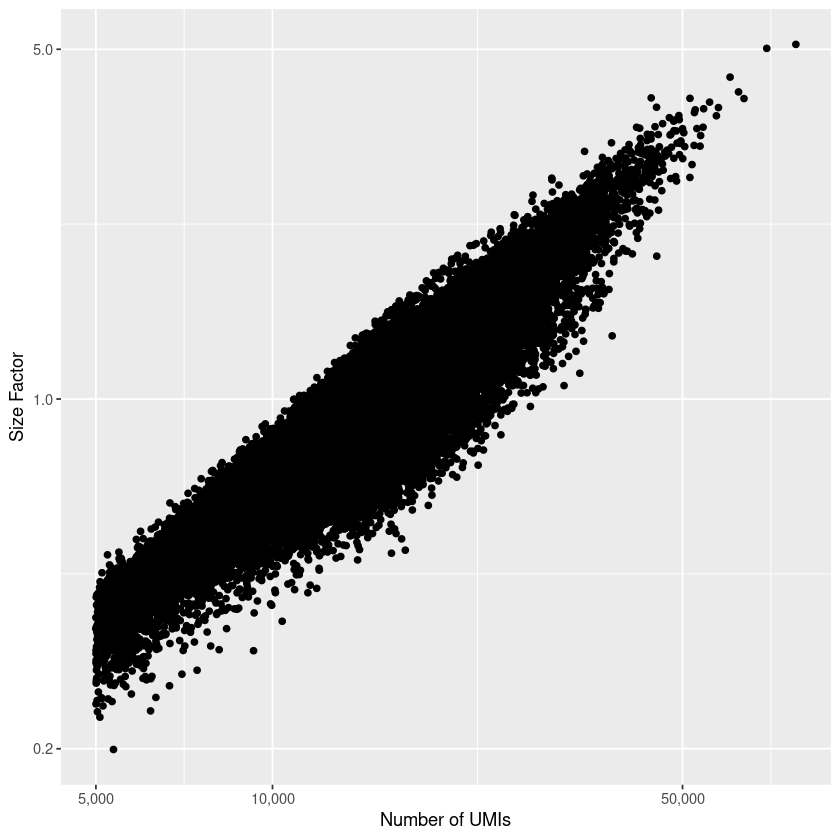

In [3]:
#now run the normalisation
#number of cells in each cluster should be at least twice that of the largest 'sizes'
min.clust = min(table(clusts))/2
new_sizes = c(floor(min.clust/3), floor(min.clust/2), floor(min.clust))
sce = computeSumFactors(sce, clusters = clusts, sizes = new_sizes, max.cluster.size = 3000)


ggplot(data = data.frame(X = lib.sizes, Y = sizeFactors(sce)),
              mapping = aes(x = X, y = Y)) +
  geom_point() +
  scale_x_log10(breaks = c(5000, 10000, 50000, 100000), labels = c("5,000", "10,000", "50,000", "100,000") ) +
  scale_y_log10(breaks = c(0.2, 1, 5)) +
  labs(x = "Number of UMIs", y = "Size Factor")

In [4]:
write.table(sizeFactors(sce), quote = F, col.names = F, row.names = F, file = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/mlnt2/PhD_MT07_Mixl1/4_norm/sizefactors.tab")

In [5]:
sessionInfo()

R version 3.6.1 (2019-07-05)
Platform: x86_64-pc-linux-gnu (64-bit)
Running under: Scientific Linux 7.7 (Nitrogen)

Matrix products: default
BLAS:   /usr/local/software/spack/spack-0.11.2/opt/spack/linux-rhel7-x86_64/gcc-5.4.0/r-3.6.1-zrytncqvsnw5h4dl6t6njefj7otl4bg4/rlib/R/lib/libRblas.so
LAPACK: /usr/local/software/spack/spack-0.11.2/opt/spack/linux-rhel7-x86_64/gcc-5.4.0/r-3.6.1-zrytncqvsnw5h4dl6t6njefj7otl4bg4/rlib/R/lib/libRlapack.so

locale:
 [1] LC_CTYPE=en_GB.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_GB.UTF-8        LC_COLLATE=en_GB.UTF-8    
 [5] LC_MONETARY=en_GB.UTF-8    LC_MESSAGES=en_GB.UTF-8   
 [7] LC_PAPER=en_GB.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_GB.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] parallel  stats4    stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
 [1] cowplot_1.0.0               irlba_2.3.3 